# Imbalanced Data

## 01. 불균형 데이터 문제

실제 분류 문제에서는 한쪽 클래스의 비율이 매우 적은 경우가 많다.

예)
- 사기 거래 탐지
- 희귀 질환 판별
- 장애 탐지
- 이탈 고객 예측

이처럼 소수 클래스가 중요한 문제에서는 정확도(accuracy)만 보면 모델을 잘못 해석할 수 있다.

예를 들어 전체 데이터의 95%가 정상 클래스이고 5%만 이상 클래스라면,
모델이 모든 데이터를 정상이라고만 예측해도 정확도는 95%가 나온다.

하지만 이 모델은 정작 중요한 소수 클래스를 전혀 찾아내지 못하므로 좋은 모델이라고 볼 수 없다.


## 02. 예제 데이터 준비

sklearn의 make_classification을 사용해 클래스 비율이 95 : 5 인 불균형 데이터를 생성한다.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [19]:
from sklearn.datasets import make_classification

# make_classification
# - n_samples: 전체 샘플 수
# - n_features: 전체 특성 수
# - n_informative: 실제로 예측에 도움이 되는 특성 수
# - n_redundant: informative 특성의 선형 결합으로 만들어지는 중복 특성 수
# - weights=[0.95, 0.05]: 클래스 0이 95%, 클래스 1이 5%가 되도록 생성
# - flip_y: 일부 라벨에 노이즈를 섞음
# - random_state: 실행할 때마다 동일한 데이터 생성
X, y = make_classification(
    n_samples=5000,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    weights=[0.95, 0.05],
    flip_y=0.01,
    class_sep=1.0,
    random_state=42
)

# 확인용 DataFrame
imbalance_df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])
imbalance_df['target'] = y
imbalance_df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,target
0,0.988922,-0.727682,-1.642290,-0.636899,-0.586186,1.837144,0.741970,-0.280699,1.195935,-0.180942,0
1,0.471336,4.464405,0.714992,-3.881001,-1.392344,-1.920335,0.165704,0.286723,-0.283905,3.321956,0
2,-0.352405,3.335213,-1.422288,1.431640,-1.328054,0.446401,-2.303337,1.602839,-1.728839,1.556287,0
3,-1.100063,5.443978,-1.098840,3.496062,-2.540364,2.209469,-0.442214,1.768249,-3.091718,2.818999,0
4,0.361743,2.608701,-0.779896,0.494326,-1.075382,-0.006072,-0.099266,2.585057,-1.102943,0.639876,0


In [20]:
# 클래스 분포 확인
# np.bincount(y): 각 클래스(0, 1)의 개수를 세어준다.
class_counts = np.bincount(y)
print('클래스 개수:', class_counts)
print('클래스 비율:', class_counts / class_counts.sum())


클래스 개수: [4725  275]
클래스 비율: [0.945 0.055]


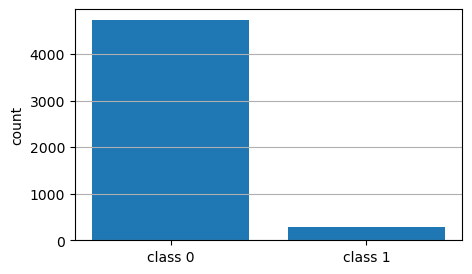

In [21]:
import matplotlib.pyplot as plt

# 막대그래프로 클래스 불균형 정도 시각화
plt.figure(figsize=(5, 3))
plt.bar(['class 0', 'class 1'], class_counts)
plt.ylabel('count')
plt.grid(axis='y')
plt.show()

## 03. 데이터 분리

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
print('학습셋 클래스 분포:', np.bincount(y_train))
print('평가셋 클래스 분포:', np.bincount(y_test))

(4000, 10) (4000,)
(1000, 10) (1000,)
학습셋 클래스 분포: [3780  220]
평가셋 클래스 분포: [945  55]


## 04. 평가 함수 준비

이후 여러 모델을 같은 기준으로 비교하기 위해 공통 평가 함수를 먼저 만들어 둔다.

비교할 지표
- accuracy
- precision
- recall
- f1-score
- confusion matrix
- average precision

In [23]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, average_precision_score
)

def evaluate_binary_classifier(model, X_train, X_test, y_train, y_test, threshold=0.5):
    # 모델 학습
    model.fit(X_train, y_train)

    # predict_proba()[:, 1]
    # - 양성 클래스(1)에 대한 확률값만 가져온다.
    y_proba = model.predict_proba(X_test)[:, 1]

    # threshold 기준으로 최종 클래스 결정
    y_pred = (y_proba >= threshold).astype(int)

    result = {
        'model': model,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'classification_report': classification_report(y_test, y_pred, zero_division=0),
        'y_proba': y_proba,
        'y_pred': y_pred,
        # Precision-Recall Curve 아래 면적
        # threshold 를 바꿔가며 precision/recall 의 전체 성능을 종합 평가
        'ap': average_precision_score(y_test, y_proba)
    }
    return result


## 05. 기본 LogisticRegression

먼저 아무런 불균형 보정 없이 기본 LogisticRegression을 학습한다.
스케일 차이 영향을 줄이기 위해 StandardScaler를 함께 사용한다.

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000, random_state=42))
])

baseline_result = evaluate_binary_classifier(
    baseline_model, 
    X_train, X_test, y_train, y_test
    )

print("Baseline")
print(baseline_result['classification_report'])
print('confusion matrix:\n', baseline_result['confusion_matrix'])

Baseline
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       945
           1       0.57      0.07      0.13        55

    accuracy                           0.95      1000
   macro avg       0.76      0.53      0.55      1000
weighted avg       0.93      0.95      0.93      1000

confusion matrix:
 [[942   3]
 [ 51   4]]


## 06. class_weight='balanced'

불균형 데이터 처리의 가장 쉬운 방법 중 하나는 모델 학습 시 소수 클래스에 더 큰 가중치를 주는 것이다.

LogisticRegression에서는 class_weight='balanced' 옵션으로 클래스 빈도에 반비례하도록 자동 가중치를 부여할 수 있다.

In [25]:
balanced_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42))
])

balanced_result = evaluate_binary_classifier(
    balanced_model, 
    X_train, X_test, y_train, y_test
    )

print("Balanced")
print(balanced_result['classification_report'])
print('confusion matrix:\n', balanced_result['confusion_matrix'])

Balanced
              precision    recall  f1-score   support

           0       0.99      0.74      0.84       945
           1       0.16      0.85      0.27        55

    accuracy                           0.74      1000
   macro avg       0.57      0.80      0.56      1000
weighted avg       0.94      0.74      0.81      1000

confusion matrix:
 [[696 249]
 [  8  47]]


## 07. Oversampling 개념

불균형 데이터 처리 방법은 크게 다음처럼 볼 수 있다.

1. class_weight
   - 데이터 개수는 그대로 두고
   - 학습 시 손실 계산에서 소수 클래스 비중을 더 크게 둔다.

2. Random Oversampling
   - 소수 클래스 데이터를 단순 복제해 개수를 늘린다.

3. SMOTE
   - 소수 클래스 데이터를 단순 복제하지 않고
   - 기존 샘플 사이를 보간해 새로운 샘플을 만든다.

주의할 점
- Oversampling은 반드시 학습 데이터에만 적용해야 한다.
- 테스트 데이터까지 늘리면 평가가 왜곡된다.

## 08. imbalanced-learn import 확인

SMOTE와 RandomOverSampler는 sklearn이 아니라
imbalanced-learn 패키지에서 제공한다.

만약 아래 import에서 오류가 난다면 환경에 패키지가 없는 것이다.

설치 예시
- pip: pip install imbalanced-learn
- conda: conda install -c conda-forge imbalanced-learn

In [26]:
# %conda install -c conda-forge imbalanced-learn

In [27]:
# 불균형 데이터 처리용 패키지 import
# sklearn이 아니라 imblearn 패키지에서 가져온다.
from imblearn.over_sampling import RandomOverSampler, SMOTE

## 09. RandomOverSampler

RandomOverSampler는 소수 클래스 데이터를 단순 복제하여
클래스 균형을 맞추는 방법이다.

구현은 쉽지만
같은 데이터가 반복되므로 과적합 위험이 있다.


In [28]:
print('원본 학습 데이터 분포 : ', np.bincount(y_train))

ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)
print('ROS 적용 후 학습 데이터 분포 : ', np.bincount(y_train_ros))

# 소수 클래스에 해당하는 클래스 샘플 추출
minority_ros_X = pd.DataFrame(X_train_ros[y_train_ros == 1]).reset_index(drop=True)
# 중복 되는 행의 개수 확인
ros_unique_count = minority_ros_X.drop_duplicates().shape[0]
print('ROS 후 소수 클래스 중 유니크 행 갯수 :', ros_unique_count)
print('중복으로 추가 된 행 갯수:', len(minority_ros_X) - ros_unique_count)

원본 학습 데이터 분포 :  [3780  220]
ROS 적용 후 학습 데이터 분포 :  [3780 3780]
ROS 후 소수 클래스 중 유니크 행 갯수 : 220
중복으로 추가 된 행 갯수: 3560


In [29]:
from imblearn.pipeline import Pipeline as ImbPipeline

ros_model = ImbPipeline([
    ('oversample', RandomOverSampler(random_state=42)),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000, random_state=42))
])

ros_result = evaluate_binary_classifier(
    ros_model, 
    X_train, X_test, y_train, y_test
    )

print("ROS")
print(ros_result['classification_report'])
print('confusion matrix:\n', ros_result['confusion_matrix'])

ROS
              precision    recall  f1-score   support

           0       0.99      0.73      0.84       945
           1       0.16      0.85      0.26        55

    accuracy                           0.74      1000
   macro avg       0.57      0.79      0.55      1000
weighted avg       0.94      0.74      0.81      1000

confusion matrix:
 [[690 255]
 [  8  47]]


## 10. SMOTE

SMOTE는 Synthetic Minority Over-sampling Technique의 약자이다.

핵심 아이디어
- 소수 클래스 데이터를 단순 복제하지 않는다.
- 가까운 소수 클래스 샘플 사이를 잇는 중간 지점에
  새로운 가상 샘플을 생성한다.

즉,
RandomOverSampler보다 조금 더 자연스러운 방식으로
소수 클래스 데이터를 늘리려는 방법이다.


In [30]:
print('원본 학습 데이터 분포 : ', np.bincount(y_train))

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print('SMOTE 적용 후 학습 데이터 분포 : ', np.bincount(y_train_smote))

# 소수 클래스에 해당하는 클래스 샘플 추출
minority_smote_X = pd.DataFrame(X_train_smote[y_train_smote == 1]).reset_index(drop=True)
# 중복 되는 행의 개수 확인
smote_unique_count = minority_smote_X.drop_duplicates().shape[0]
print('SMOTE 후 소수 클래스 중 유니크 행 갯수 :', smote_unique_count)
print('중복으로 추가 된 행 갯수:', len(minority_smote_X) - smote_unique_count)

원본 학습 데이터 분포 :  [3780  220]
SMOTE 적용 후 학습 데이터 분포 :  [3780 3780]
SMOTE 후 소수 클래스 중 유니크 행 갯수 : 3780
중복으로 추가 된 행 갯수: 0


In [31]:
smote_model = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000, random_state=42))
])

smote_result = evaluate_binary_classifier(
    smote_model, 
    X_train, X_test, y_train, y_test
    )

print("SMOTE")
print(smote_result['classification_report'])
print('confusion matrix:\n', smote_result['confusion_matrix'])

SMOTE
              precision    recall  f1-score   support

           0       0.99      0.74      0.85       945
           1       0.16      0.85      0.27        55

    accuracy                           0.75      1000
   macro avg       0.58      0.80      0.56      1000
weighted avg       0.94      0.75      0.82      1000

confusion matrix:
 [[703 242]
 [  8  47]]


## 11. 결과 비교

baseline, class_weight, RandomOverSampler, SMOTE 결과를 한 번에 비교한다.

- recall이 얼마나 올라갔는가
- precision이 얼마나 떨어졌는가
- f1-score는 어떤가
- average precision은 어떤가

In [32]:
compare_df = pd.DataFrame([
    {
        'model': 'Baseline',
        'accuracy': baseline_result['accuracy'],
        'precision': baseline_result['precision'],
        'recall': baseline_result['recall'],
        'f1': baseline_result['f1'],
        'average_precision': baseline_result['ap']
    },
    {
        'model': 'class_weight=balanced',
        'accuracy': balanced_result['accuracy'],
        'precision': balanced_result['precision'],
        'recall': balanced_result['recall'],
        'f1': balanced_result['f1'],
        'average_precision': balanced_result['ap']
    },
    {
        'model': 'RandomOverSampler',
        'accuracy': ros_result['accuracy'],
        'precision': ros_result['precision'],
        'recall': ros_result['recall'],
        'f1': ros_result['f1'],
        'average_precision': ros_result['ap']
    },
    {
        'model': 'SMOTE',
        'accuracy': smote_result['accuracy'],
        'precision': smote_result['precision'],
        'recall': smote_result['recall'],
        'f1': smote_result['f1'],
        'average_precision': smote_result['ap']
    }
])

compare_df


,model,accuracy,precision,recall,f1,average_precision
0,Baseline,0.946,0.571429,0.072727,0.129032,0.357437
1,class_weight=balanced,0.743,0.158784,0.854545,0.267806,0.273711
2,RandomOverSampler,0.737,0.155629,0.854545,0.263305,0.283163
3,SMOTE,0.750,0.162630,0.854545,0.273256,0.277461


## 12. PR Curve

불균형 데이터에서는 ROC Curve보다 PR Curve를 더 중요하게 보는 경우가 많다.

- 소수 클래스 탐지가 핵심인 문제에서는
- precision과 recall의 균형이 더 직접적으로 중요하기 때문이다.

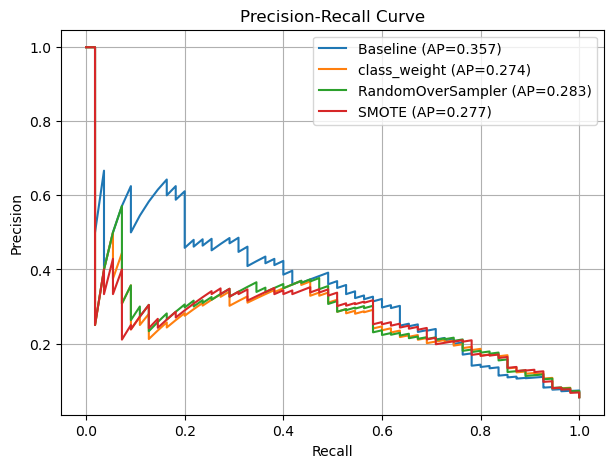

In [33]:
from sklearn.metrics import precision_recall_curve

# 각 모델의 양성 클래스 확률값
baseline_proba = baseline_result['y_proba']
balanced_proba = balanced_result['y_proba']
ros_proba = ros_result['y_proba']
smote_proba = smote_result['y_proba']

# precision_recall_curve
# - y_test: 실제값
# - proba: 양성(1) 클래스 확률값
# 반환값:
# - precisions: threshold별 precision
# - recalls: threshold별 recall
# - thresholds: 임계값 목록
b_precision, b_recall, _ = precision_recall_curve(y_test, baseline_proba)
cw_precision, cw_recall, _ = precision_recall_curve(y_test, balanced_proba)
ros_precision, ros_recall, _ = precision_recall_curve(y_test, ros_proba)
sm_precision, sm_recall, _ = precision_recall_curve(y_test, smote_proba)

plt.figure(figsize=(7, 5))
plt.plot(b_recall, b_precision, label=f'Baseline (AP={baseline_result["ap"]:.3f})')
plt.plot(cw_recall, cw_precision, label=f'class_weight (AP={balanced_result["ap"]:.3f})')
plt.plot(ros_recall, ros_precision, label=f'RandomOverSampler (AP={ros_result["ap"]:.3f})')
plt.plot(sm_recall, sm_precision, label=f'SMOTE (AP={smote_result["ap"]:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()


## 13. Threshold 조정

predict()는 보통 0.5를 기준으로 최종 클래스를 결정한다.

하지만 불균형 데이터에서는 0.5가 항상 최적의 기준은 아니다.

예를 들어
- 사기 탐지처럼 놓치면 큰 손해가 나는 문제는 recall을 더 높이고 싶을 수 있다.
- 잘못 탐지하면 비용이 큰 문제는 precision을 더 높이고 싶을 수 있다.

따라서 threshold를 직접 바꾸어
precision / recall trade-off를 조절할 수 있다.

In [34]:
def evaluate_threshold(y_true, y_proba, thresholds):
    rows = []

    for threshold in thresholds:
        # threshold 이상이면 양성(1), 아니면 음성(0)
        y_pred = (y_proba >= threshold).astype(int)

        rows.append({
            'threshold': threshold,
            'accuracy': accuracy_score(y_true, y_pred),
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall': recall_score(y_true, y_pred, zero_division=0),
            'f1': f1_score(y_true, y_pred, zero_division=0)
        })

    return pd.DataFrame(rows)

# 예시: 기본 모델의 threshold를 여러 값으로 바꿔 본다.
thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]
threshold_df = evaluate_threshold(y_test, baseline_result['y_proba'], thresholds)
threshold_df


,threshold,accuracy,precision,recall,f1
0,0.5,0.946,0.571429,0.072727,0.129032
1,0.4,0.948,0.615385,0.145455,0.235294
2,0.3,0.943,0.466667,0.254545,0.329412
3,0.2,0.928,0.365079,0.418182,0.389831
4,0.1,0.856,0.233533,0.709091,0.351351


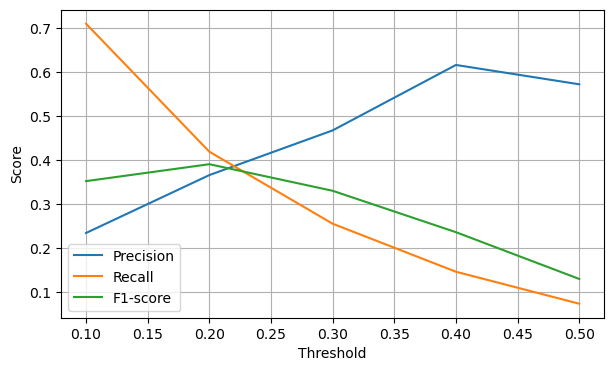

In [35]:
plt.figure(figsize=(7, 4))
plt.plot(threshold_df['threshold'], threshold_df['precision'], label='Precision')
plt.plot(threshold_df['threshold'], threshold_df['recall'], label='Recall')
plt.plot(threshold_df['threshold'], threshold_df['f1'], label='F1-score')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()
